In [3]:
import pandas as pd
df = pd.read_csv('diabetes.csv')

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<Figure size 1200x800 with 0 Axes>

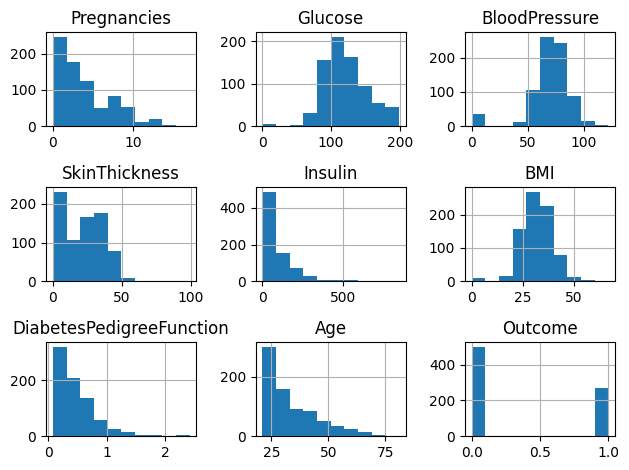

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
df.hist()
plt.tight_layout()

/var/folders/dl/ht1b4df975n2m70x5glhtk280000gn/T/ipykernel_90647/3183265984.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df.Outcome==0][col], hist=False, axlabel=False,kde_kws={'linestyle':'-', 'color':'black', 'label':"No Diabetes"})
/var/folders/dl/ht1b4df975n2m70x5glhtk280000gn/T/ipykernel_90647/3183265984.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new func

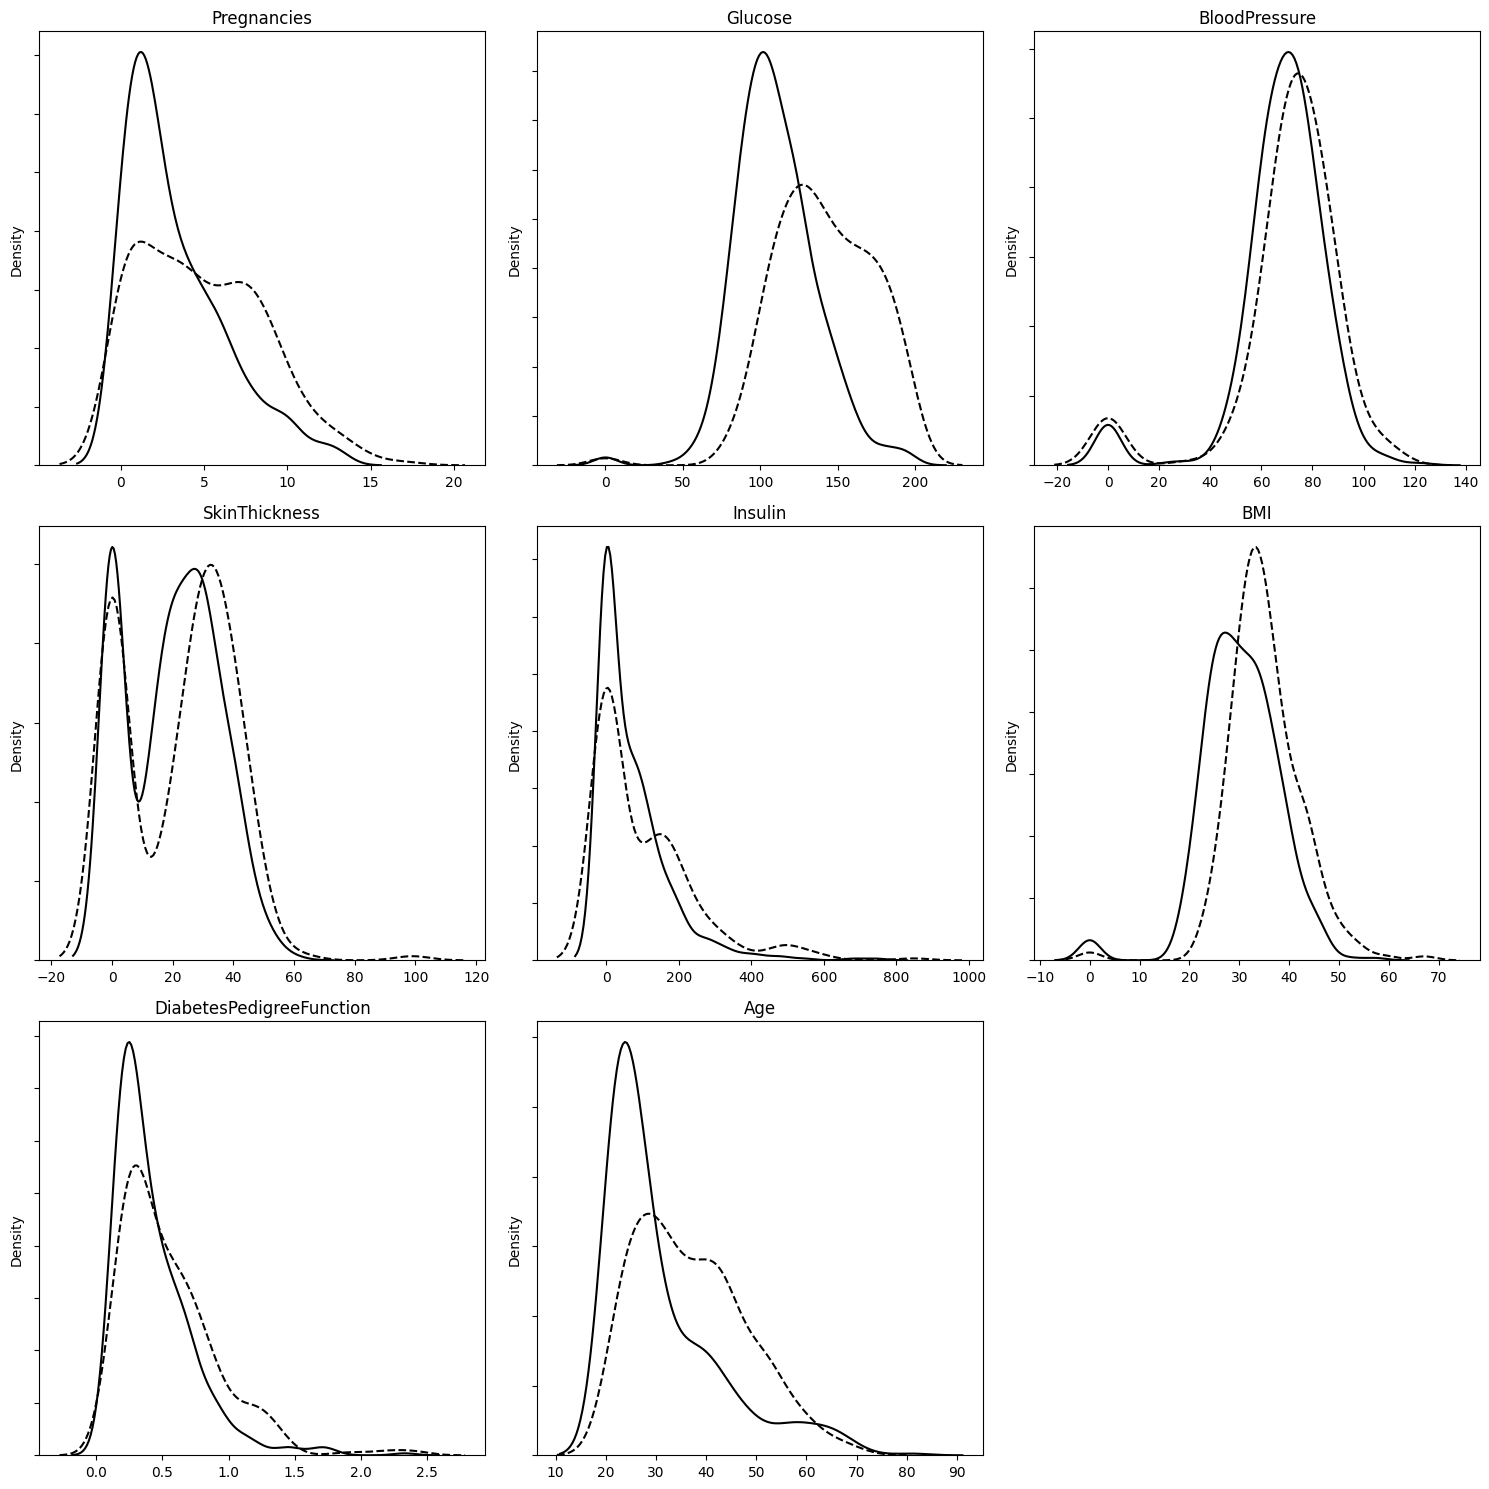

In [7]:
import seaborn as sns
plt.subplots(3,3, figsize=(15, 15))

for idx, col in enumerate(df.columns):
    ax = plt.subplot(3,3,idx+1)
    ax.yaxis.set_ticklabels([])
    sns.distplot(df.loc[df.Outcome==0][col], hist=False, axlabel=False,kde_kws={'linestyle':'-', 'color':'black', 'label':"No Diabetes"})
    sns.distplot(df.loc[df.Outcome==1][col], hist=False, axlabel=False,kde_kws={'linestyle':'--', 'color':'black', 'label':"Diabetes"})
    ax.set_title(col)

plt.subplot(3,3,9).set_visible(False)
plt.tight_layout()


In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
for col in df.columns:
    missing = df.loc[df[col]==0].shape[0]
    print(col + ": " + str(missing))

Pregnancies: 111
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11
DiabetesPedigreeFunction: 0
Age: 0
Outcome: 500


In [12]:
import numpy as np 
df['Glucose'] = df['Glucose'].replace(0, np.nan)
df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)
df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)
df['Insulin'] = df['Insulin'].replace(0, np.nan)
df['BMI'] = df['BMI'].replace(0, np.nan)

In [14]:
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].mean())
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].mean())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].mean())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())

In [15]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1


In [16]:
from sklearn import preprocessing

df_scaled = preprocessing.scale(df)

In [17]:
df_scaled = pd.DataFrame(df_scaled, columns = df.columns)

In [ ]:
df_scaled['Outcome'] = df['Outcome']
df = df_scaled


In [20]:
df.describe().loc[['mean', 'std', 'max'],].round(2).abs()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
mean,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.35
std,1.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00,0.48
max,3.91,2.54,4.1,7.95,8.13,5.04,5.88,4.06,1.00


In [21]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [43]:
model = Sequential()
model.add(Dense(32, activation='relu', input_dim = 8))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

In [44]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=30)

In [45]:
model.fit(X_train, y_train, epochs=200, validation_data=(X_test, y_test), callbacks=[early_stop])

Epoch 1/200


2025-02-12 13:06:49.728283: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


20/20 [==============================] - 1s 14ms/step - loss: 0.5830 - accuracy: 0.7020 - val_loss: 0.5722 - val_accuracy: 0.6623
Epoch 2/200
20/20 [==============================] - 0s 5ms/step - loss: 0.5124 - accuracy: 0.7476 - val_loss: 0.5341 - val_accuracy: 0.7078


2025-02-12 13:06:50.104874: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Epoch 3/200
20/20 [==============================] - 0s 6ms/step - loss: 0.4884 - accuracy: 0.7655 - val_loss: 0.5235 - val_accuracy: 0.7078
Epoch 4/200
20/20 [==============================] - 0s 5ms/step - loss: 0.4792 - accuracy: 0.7655 - val_loss: 0.5097 - val_accuracy: 0.7078
Epoch 5/200
20/20 [==============================] - 0s 5ms/step - loss: 0.4747 - accuracy: 0.7720 - val_loss: 0.5094 - val_accuracy: 0.7208
Epoch 6/200
20/20 [==============================] - 0s 5ms/step - loss: 0.4710 - accuracy: 0.7720 - val_loss: 0.5029 - val_accuracy: 0.7338
Epoch 7/200
20/20 [==============================] - 0s 6ms/step - loss: 0.4689 - accuracy: 0.7671 - val_loss: 0.5044 - val_accuracy: 0.7338
Epoch 8/200
20/20 [==============================] - 0s 5ms/step - loss: 0.4690 - accuracy: 0.7704 - val_loss: 0.5027 - val_accuracy: 0.7403
Epoch 9/200
20/20 [==============================] - 0s 5ms/step - loss: 0.4680 - accuracy: 0.7720 - val_loss: 0.4965 - val_accuracy: 0.7532
Epoch 10/200


In [46]:
scores = model.evaluate(X_train, y_train)

20/20 [==============================] - 0s 4ms/step - loss: 0.4645 - accuracy: 0.7752


In [47]:
scores = model.evaluate(X_test, y_test)

5/5 [==============================] - 0s 4ms/step - loss: 0.4921 - accuracy: 0.7597


In [49]:
from sklearn.metrics import confusion_matrix, classification_report 
predictions = (model.predict(X_test) > 0.5).astype("int32")
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

5/5 [==============================] - 0s 2ms/step
[[82 17]
 [20 35]]
              precision    recall  f1-score   support

           0       0.80      0.83      0.82        99
           1       0.67      0.64      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.76      0.76       154



2025-02-12 13:08:19.822080: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


In [50]:
from sklearn.metrics import roc_curve
y_test_pred_probs = model.predict(X_test)
FPR, TPR, _ = roc_curve(y_test, y_test_pred_probs)


5/5 [==============================] - 0s 1ms/step


Text(0, 0.5, 'True Positive Rate')

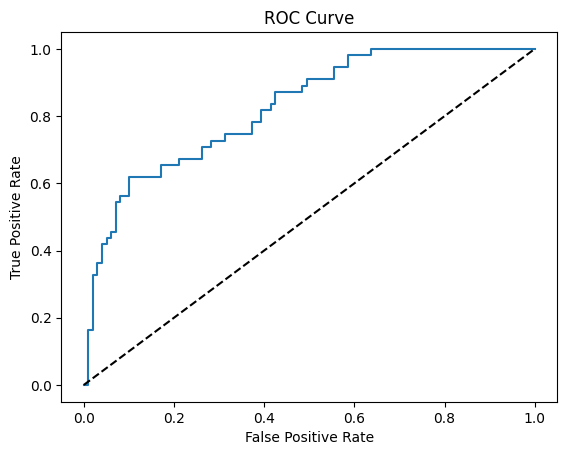

In [51]:
plt.plot(FPR, TPR)
plt.plot([0, 1], [0, 1], '--', color='black')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')